In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [8]:
df = pd.read_csv("/Users/mayurimamdi/Downloads/Customer-Churn-Records.csv")

In [9]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [11]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


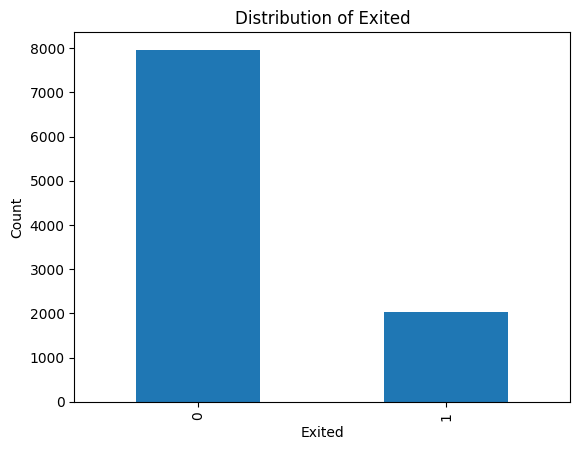

In [14]:
df['Exited'].value_counts().plot(kind='bar')
plt.title('Distribution of Exited')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

### This dataset is highly imbalanced, Need to use smote technique

In [15]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
leak_cols = ['Complain', 'Satisfaction Score']
df = df.drop(leak_cols, axis=1)

In [18]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [21]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Exited
0    6370
1    1630
Name: count, dtype: int64
Exited
0    6370
1    6370
Name: count, dtype: int64


In [22]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote, y_train_smote)
y_pred_rfc = rfc.predict(X_test)
print("Random Forest Classifier:")
print(classification_report(y_test, y_pred_rfc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rfc))
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
print(f"Accuracy: {accuracy_rfc:.4f}")

Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1592
           1       0.61      0.64      0.62       408

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000

Confusion Matrix:
[[1422  170]
 [ 146  262]]
Accuracy: 0.8420


In [23]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f}")

Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1592
           1       0.40      0.54      0.46       408

    accuracy                           0.74      2000
   macro avg       0.63      0.67      0.64      2000
weighted avg       0.77      0.74      0.75      2000

Confusion Matrix:
[[1255  337]
 [ 186  222]]
Accuracy: 0.7385


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBoost, SVM, and KNN can also be implemented similarly by importing the respective classes from sklearn and following the same steps for training and evaluation.

In [24]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Classifier:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}")

XGBoost Classifier:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1592
           1       0.57      0.62      0.60       408

    accuracy                           0.83      2000
   macro avg       0.74      0.75      0.74      2000
weighted avg       0.83      0.83      0.83      2000

Confusion Matrix:
[[1403  189]
 [ 153  255]]
Accuracy: 0.8290


In [25]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_smote, y_train_smote)
y_pred_dtc = dtc.predict(X_test)
print("Decision Tree Classifier:")
print(classification_report(y_test, y_pred_dtc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtc))
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Accuracy: {accuracy_dtc:.4f}")


Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1592
           1       0.43      0.61      0.51       408

    accuracy                           0.76      2000
   macro avg       0.66      0.70      0.67      2000
weighted avg       0.80      0.76      0.77      2000

Confusion Matrix:
[[1268  324]
 [ 159  249]]
Accuracy: 0.7585


In [26]:
svc = SVC(random_state=42, class_weight='balanced')
svc.fit(X_train_smote, y_train_smote)
y_pred_svc = svc.predict(X_test)
print("Support Vector Classifier:")
print(classification_report(y_test, y_pred_svc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy: {accuracy_svc:.4f}")

Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.85      0.39      0.54      1592
           1       0.24      0.73      0.36       408

    accuracy                           0.46      2000
   macro avg       0.54      0.56      0.45      2000
weighted avg       0.72      0.46      0.50      2000

Confusion Matrix:
[[622 970]
 [110 298]]
Accuracy: 0.4600


In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)
y_pred_knn = knn.predict(X_test)
print("K-Nearest Neighbors Classifier:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy_knn:.4f}")

K-Nearest Neighbors Classifier:
              precision    recall  f1-score   support

           0       0.80      0.58      0.67      1592
           1       0.21      0.42      0.28       408

    accuracy                           0.55      2000
   macro avg       0.50      0.50      0.48      2000
weighted avg       0.68      0.55      0.59      2000

Confusion Matrix:
[[928 664]
 [235 173]]
Accuracy: 0.5505


In [28]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, rfc.predict_proba(X_test)[:,1])

np.float64(0.8521867918021481)

In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rfc, X, y, cv=5, scoring='recall')
print(scores.mean())

0.44946764946764944


#### Comapare the models, Lets do it in a bit different way

In [30]:
from imblearn.pipeline import Pipeline

results = []

pipelines = {
    "RandomForest": Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]),

    "Logistic": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', KNeighborsClassifier())
    ]),
    "XGBoost": Pipeline([
        ('smote', SMOTE(random_state=42)),
				('model', XGBClassifier(random_state=42))
		])
}

for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Recall_1": report['1']['recall'],
        "Precision_1": report['1']['precision'],
        "F1_1": report['1']['f1-score']
    })

results_df = pd.DataFrame(results)
print(results_df)

          Model  Recall_1  Precision_1      F1_1
0  RandomForest  0.642157     0.606481  0.623810
1      Logistic  0.708333     0.384820  0.498706
2           KNN  0.634804     0.375907  0.472197
3       XGBoost  0.625000     0.574324  0.598592


#### Did the pipeline according to the model, need to chcek recall so that will know that out of all the customers who actually churned how many did the model correctly identified

### Conclusion - So in this models logistic regression has best recall but it has less precision as compared to recall since it is showing the most false positives maybe this is not the best model for this project, secondly randomforest has 0.64 recall but better precision than logistic regression and having F1 as 0.62 makes it more balanced model for this project where as knn has given bad results which makes it not suitable for this project

------------------------------------------------

--------------------------------------------------------

### Now lets see why the customers have churned, what are the possible reasons they leave

In [31]:
!pip install shap

In [32]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [33]:
import shap

In [34]:
import shap
print(shap.__version__)

0.51.0


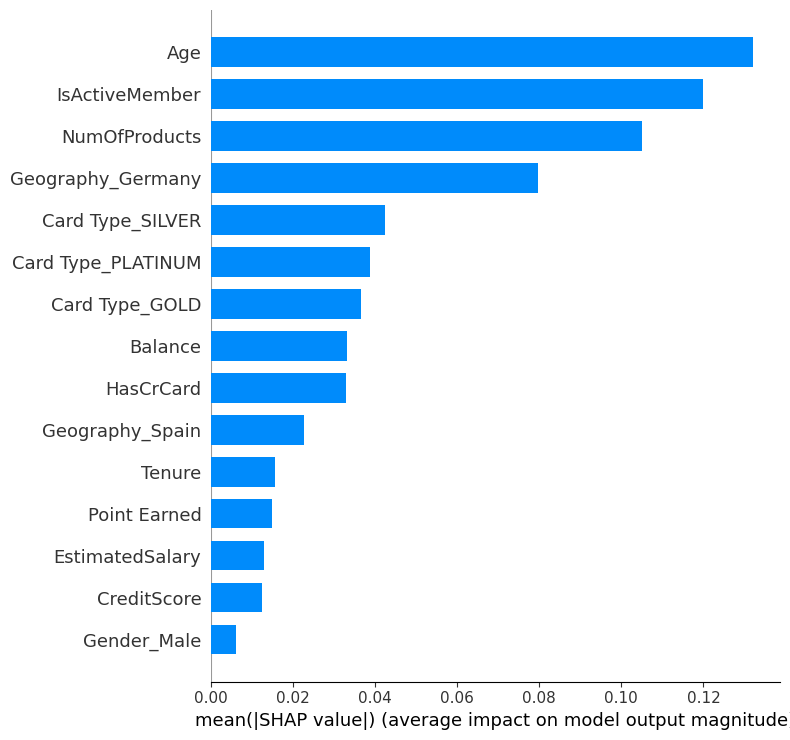

In [ ]:
explainer = shap.TreeExplainer(rfc)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

#### Lets try THRESHOLD TUNING (BOOST RECALL)

In [37]:
y_probs = pipelines["RandomForest"].predict_proba(X_test)[:, 1]

In [ ]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_probs >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.96      0.53      0.68      1592
           1       0.33      0.90      0.48       408

    accuracy                           0.61      2000
   macro avg       0.64      0.72      0.58      2000
weighted avg       0.83      0.61      0.64      2000


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.70      0.80      1592
           1       0.41      0.82      0.55       408

    accuracy                           0.72      2000
   macro avg       0.67      0.76      0.67      2000
weighted avg       0.83      0.72      0.75      2000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1592
           1       0.50      0.74      0.60       408

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.84   

tuned the decision threshold to prioritise recall, reducing missed churners at the cost of increased false positives

### Business Dashboard

In [40]:
import matplotlib.pyplot as plt

model = pipelines["RandomForest"].named_steps["model"]

importances = model.feature_importances_
features = X_train.columns

fi = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(fi.head(10))

              Feature  Importance
1                 Age    0.195342
3             Balance    0.103151
4       NumOfProducts    0.099557
6      IsActiveMember    0.099392
7     EstimatedSalary    0.090329
8        Point Earned    0.086307
0         CreditScore    0.084063
9   Geography_Germany    0.060489
2              Tenure    0.056508
14   Card Type_SILVER    0.024955


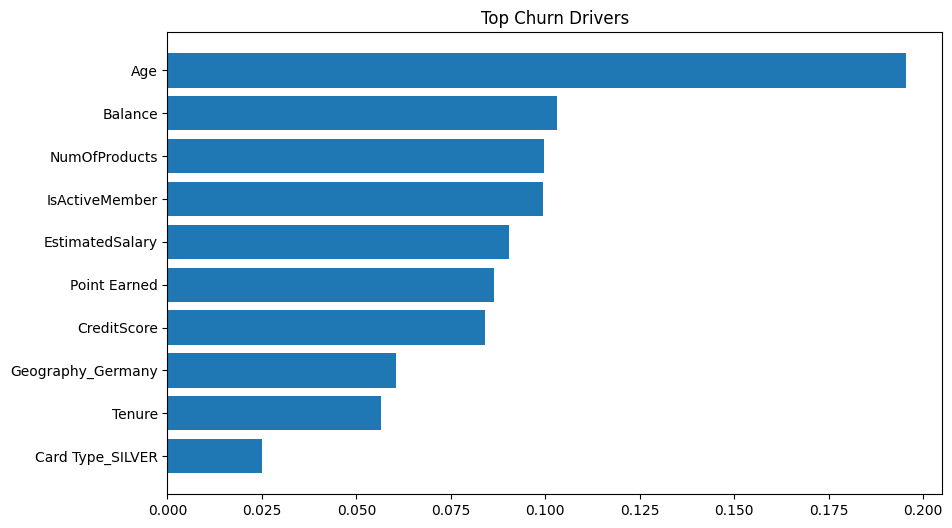

In [41]:
plt.figure(figsize=(10,6))
plt.barh(fi["Feature"][:10], fi["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top Churn Drivers")
plt.show()

The strongest churn drivers are customer age, balance and number of products used indicating less engangements lead to churning 